<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retrieval Augmented Generation (Sparse retrieval)

Contents:

0. LLM Loading and utility function definition
1. Indexing
2. Retrieval
3. Augmentation
4. Generation

## Model Loading and Utility functions

Load the model weights using the transformers library, and define utility functions

In [ ]:
import torch
from transformers import pipeline

MODEL_ID = "unsloth/Llama-3.2-3B-Instruct"

pipe = pipeline(
    "text-generation",
    model=MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

print("Loaded", MODEL_ID, "on", pipe.model.device)

In [ ]:
def make_message(system_content, user_content):
    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content},
    ]

def fetch_response(response):
    return response[0]["generated_text"][-1]["content"]

## The RAG flow

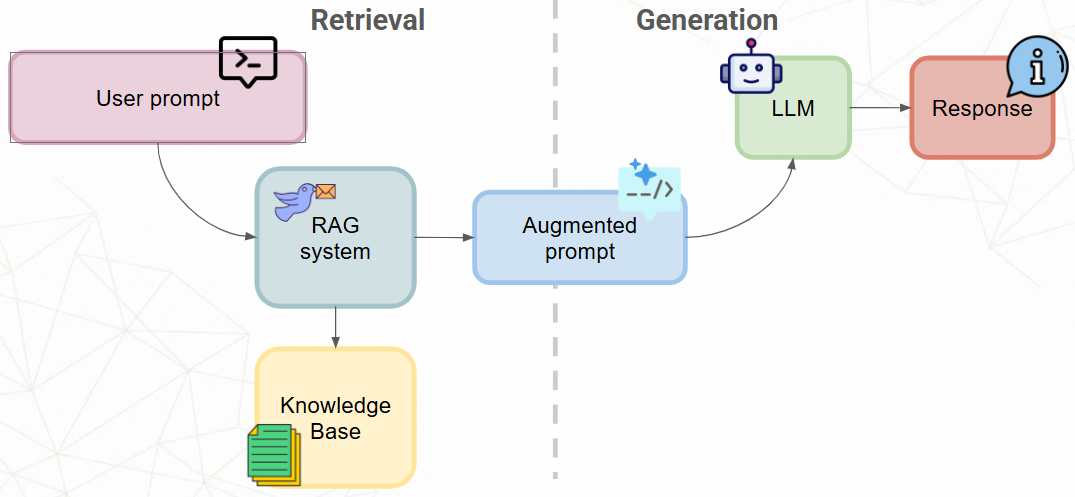

## Loading the required libraries


Fetching data from the internet: [feedparser](https://github.com/kurtmckee/feedparser)\
Indexing: [pyterrier](https://pyterrier.readthedocs.io/en/latest/)\
Retrieval: BM-25

In [ ]:
!pip install python-terrier feedparser

In [ ]:
# import the necessary libraries like feedparser, pandas, and pyterrier
# initialize pyterrier


## Failure case without RAG

We observe the response of the trained model with no external source of information

In [ ]:
system_prompt = "You are a helpful financial assistant."

query = "What specific news events or reports are driving Tesla's (TSLA) stock price this week?"

In [ ]:

# Format the message_without_rag using your helper function


In [ ]:
# Generate response_without_rag using pipe


In [ ]:
# Extract without_rag_answer using your helper function


## Fetching live data

We will chose the Live Yahoo Finance RSS Feed for Tesla (TSLA) for this demonstration.The website contains updated collection of tesla related news article.

https://feeds.finance.yahoo.com/rss/2.0/headline?s=TSLA&region=US&lang=en-US

In [ ]:
# create the feed using the parse method

In [ ]:
# Build our docs_df database

In [ ]:
# Convert to DataFrame

## Indexing

We use pyterrier to index the fetched data.


Folder: "./tesla_news_index"

In [ ]:
# Create an indexer using IterDictIndexer class

In [ ]:
# Index the documents using index method


## Retrieval

We use BM25 to rank the chunks and retrieve the top-3 relevant chunks

In [ ]:
# Create the BM25 Retriever using BatchRetrieve

In [ ]:
# Search the PyTerrier index using search method



In [ ]:
# Merge into top_docs our docs_df and search_results to see the full content


In [ ]:
# Combine the top 3 articles into a single block of context


In [ ]:
#print context

## Augmentation

The prompt is augmented with the context of the retrieved chunks

In [ ]:
# Define a strict RAG system prompt
rag_system_prompt = """You are a highly accurate financial analyst.
You will be provided with live context from a news database.
Answer the user's question ONLY using the provided context."""



In [ ]:
# Combine Context and Query for the user prompt


## Generation

The LLM is prompted with the augmented query

In [ ]:
# Format the message_with_rag using your helper function



In [ ]:
# Generate response_with_rag

In [ ]:
# Extract with_rag_answer using your helper function

## Comparison

We compare the LLM generated answer with that of a RAG implementation on the same LLM

In [ ]:
print("="*80)
print(f"QUESTION: {query}")
print("="*80)

print("\nWITHOUT RAG (Model refuses or hallucinates):")
print(without_rag_answer)

print("\nWITH RAG (Grounded in Live Database):")
print(with_rag_answer)



In [ ]:
print("\n" + "="*80)
print("EVIDENCE CITED (BM25 Top 3 Retrieved Articles):")
print("="*80)
for i, row in top_docs.iterrows():
    print(f"Rank {i+1} (Score: {row['score']:.2f})")
    print(f"Text: {row['text']}")
    print("-" * 50)

## Conclusion

The LLM can answer questions beyond its knowledge by utilizing live data and RAG pipeline.